# Density-Based Clustering

## Introduction

Density-Based Clustering is an **unsupervised learning** technique that forms clusters based on the **density of data points**. Regions with high point density form clusters, while low-density regions are treated as boundaries or noise.

---

## Types of Density-Based Clustering

1. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
2. OPTICS (Ordering Points To Identify the Clustering Structure)

---

## Limitations of K-Means

K-Means has several drawbacks:

- The number of clusters (**K**) must be specified beforehand.
- The Elbow Method for selecting **K** can be ambiguous.
- It is sensitive to outliers.
- It performs poorly on non-spherical or arbitrarily shaped datasets.

---

# DBSCAN

DBSCAN groups data points based on density rather than distance to centroids.

## Hyperparameters

### `eps` (Epsilon)

- Radius of the neighborhood around a data point.
- Determines which neighboring points are considered close.

### `min_samples` (Minimum Points)

- Minimum number of points required within the epsilon neighborhood for a point to be considered a **core point**.

---

## Types of Points

### Core Point

A point whose epsilon neighborhood contains at least `min_samples` points.

$$
|\mathcal{N}_{\varepsilon}(p)| \geq \text{min\_samples}
$$

### Border Point

- Has fewer than `min_samples` points in its epsilon neighborhood.
- Lies within the epsilon neighborhood of at least one core point.

### Noise (Outlier) Point

- Is neither a core point nor a border point.
- Does not belong to any cluster.

![](./images/img4.png)

---

## Density-Connected Points

Two points are **density-connected** if they are connected through a chain of **core points**, where consecutive points are within the epsilon distance.

Density-connected points belong to the **same cluster**.

---

## DBSCAN Algorithm

### Step 1

Identify every point as one of the following:
- Core point
- Border point
- Noise point

### Step 2

For each **unclustered core point**:

1. Create a new cluster.
2. Add all unclustered points that are **density-connected** to the current core point into the cluster.

### Step 3

Assign each unclustered **border point** to the cluster of its nearest density-connected core point.

### Step 4

Leave all **noise points** unclustered.

---

## Advantages

- No need to specify the number of clusters beforehand.
- Can discover clusters of arbitrary shapes.
- Robust to outliers since noise points are identified automatically.

## Limitations

- Choosing appropriate values for `eps` and `min_samples` can be difficult.
- Performance degrades when clusters have significantly different densities.
- Less effective in high-dimensional data due to the curse of dimensionality.

# Implementation

In [1]:
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt


X = np.array([[1, 2], [2, 2], [2, 3],[8, 7], [8, 8], [25, 80]])


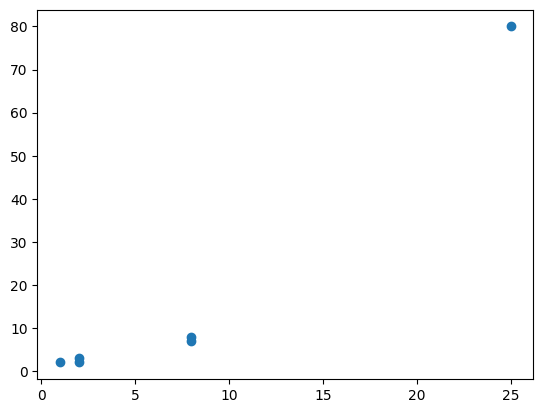

In [2]:
plt.scatter(X[:, 0], X[:, 1])
plt.show()


In [3]:
db = DBSCAN(eps = 10, min_samples= 2)
db.fit(X)
db.labels_

array([ 0,  0,  0,  0,  0, -1])

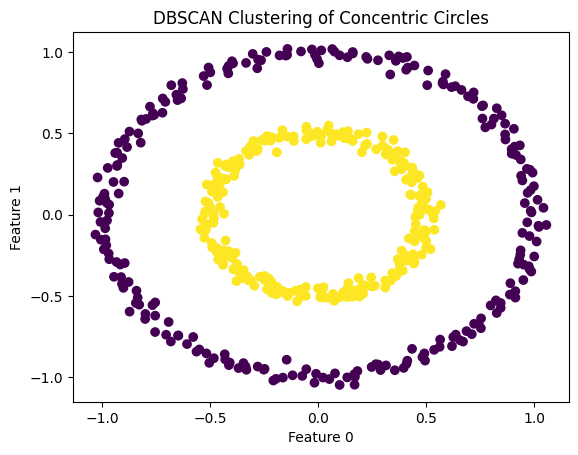

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
import numpy as np

# Create a concentric circle dataset
X, _ = make_circles(n_samples=500, factor=.5, noise=.03, random_state=4)

# Apply DBSCAN to the dataset
dbscan = DBSCAN(eps=0.1, min_samples=5)
clusters = dbscan.fit_predict(X)

# Plotting
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', marker='o')
plt.title("DBSCAN Clustering of Concentric Circles")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

# OPTICS (Ordering Points To Identify the Clustering Structure)

## Introduction

OPTICS is a **density-based clustering algorithm** that extends DBSCAN. It is designed to handle datasets with **varying density clusters**, where DBSCAN fails due to a fixed density threshold.

---

## Motivation

DBSCAN assumes a **constant density** for all clusters using fixed parameters `eps` and `min_samples`. This leads to issues:

- Cannot detect clusters with varying densities
- May split sparse clusters incorrectly
- May mark sparse cluster points as noise

OPTICS overcomes this limitation by:
- Not requiring a fixed global `eps`
- Producing a **density-based ordering of points**
- Supporting clusters of varying densities

---

## Key Idea

OPTICS does not directly output clusters. Instead, it:

- Produces an **ordering of data points**
- Stores **reachability distance** for each point
- Uses this ordering to extract clusters using a **reachability plot**

---

## Important Concepts

### 1. Core Distance

Core distance of a point is the **smallest distance required to make it a core point**.

- Defined only if the point satisfies `min_samples`
- Otherwise, it is undefined

Intuition:
- Measures how dense the local neighborhood is

---

### 2. Reachability Distance

Reachability distance of a point `q` from a core point `p` is:

$$
\text{Reachability}(q, p) = \max(\text{core-distance}(p), \; d(p, q))
$$

- It cannot be smaller than the core distance
- Measures how “reachable” a point is from a dense region

---

## OPTICS Algorithm

### Step 1: Initialization

- Mark all points as **unprocessed**
- Initialize:
  - Ordered list
  - Priority queue (min-heap)

---

### Step 2: Processing Points

For each unprocessed point:

1. Select a random unprocessed point `p`
2. Mark `p` as processed
3. Compute core distance of `p`
4. Add `p` to ordered list

---

### Step 3: Expand Cluster Ordering

If `p` is a **core point**:

- Find neighbors within `eps`
- Compute reachability distance for each neighbor
- Add/update neighbors in priority queue (min-heap based on reachability distance)
- Process next closest point from queue

---

### Step 4: Repeat

- Continue until all points are processed
- Points not reachable from any core point remain separate

---

## Reachability Plot

A **reachability plot** is used to interpret OPTICS results:

- X-axis: Ordering of points
- Y-axis: Reachability distance

### Interpretation

- **Valleys** → Dense clusters (low reachability distance)
- **Peaks** → Separation between clusters
- **Noise points** → High reachability values

### Cluster Detection

- Clusters are extracted by **cutting valleys below a threshold**
- Different thresholds may define different clusters

---

## Properties of OPTICS

- Handles **varying density clusters**
- More robust than DBSCAN
- Does not require fixed number of clusters
- Provides clustering structure instead of direct labels

---

## Pros

- Detects clusters of varying density
- No need to predefine number of clusters
- Identifies outliers naturally
- Works for non-convex shapes

---

## Cons

- Higher memory usage (priority queue + ordering list)
- Slower than DBSCAN (~1.6× in practice)
- Does not directly assign clusters (requires post-processing via reachability plot)